In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Ler dataset CSV
# Supondo que o arquivo esteja no mesmo diretório
X = np.genfromtxt("dataset_marketing.csv", delimiter=",", skip_header=1)

In [2]:
# 2. Função da distância euclidiana
def euclidian_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2, axis=1))

In [3]:
# 3. Implementação K-means
def kmeans(X, k=3, max_iter=100):
    # 1. Inicializar centróides escolhendo k pontos aleatórios
    idx = np.random.choice(len(X), k, replace=False)
    centroids = X[idx]

    for _ in range(max_iter):
        # 2. Associação - escolher centróide mais próximo
        clusters = [[] for _ in range(k)]
        labels = np.zeros(len(X))

        for i, point in enumerate(X):
            distances = euclidian_distance(point, centroids)
            label = np.argmin(distances)
            clusters[label].append(point)
            labels[i] = label

        # 3. Guardar centróides antigos
        old_centroids = centroids.copy()

        # 4. Atualizar centróides
        for i in range(k):
            if clusters[i]:
                centroids[i] = np.mean(clusters[i], axis=0)

        # 5. Critério de parada
        if np.allclose(centroids, old_centroids):
            break
    
    return centroids, labels

In [4]:
# 4. Executar o k-means
centroids, labels = kmeans(X, k=3)

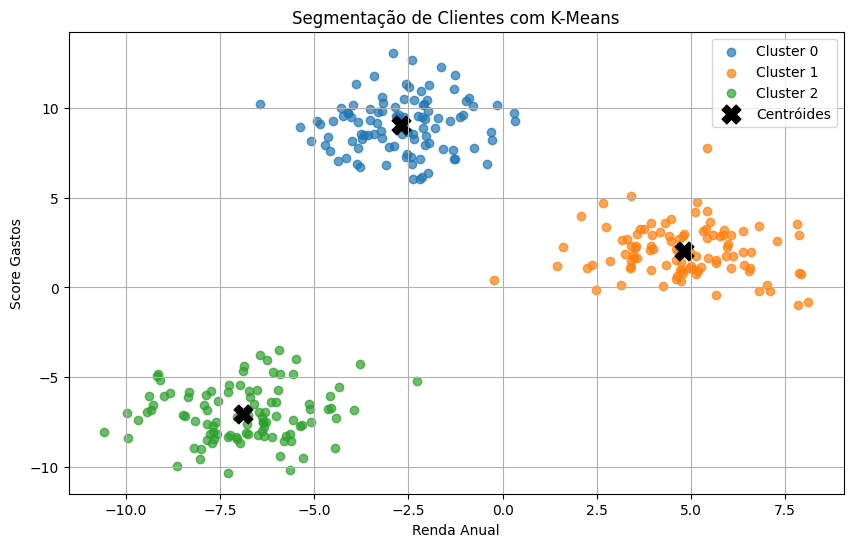

In [6]:
# 5. Plotar resultados
plt.figure(figsize=(10, 6))

for cluster_id in np.unique(labels):
    plt.scatter(
        X[labels == cluster_id, 0],
        X[labels == cluster_id, 1],
        alpha=0.7,
        label=f"Cluster {int(cluster_id)}"
    )

plt.scatter(
    centroids[:, 0], centroids[:, 1], s=180, c="black", marker="X", label="Centróides"
)

plt.title("Segmentação de Clientes com K-Means")
plt.xlabel("Renda Anual")
plt.ylabel("Score Gastos")
plt.legend()
plt.grid(True)
plt.show()

#### 1) A equipe de marketing coletou dados de 300 clientes contendo duas variáveis principais: Renda Anual (em milhares) e Score de Gastos (uma nota de 1 a 100). Eles não sabem quais são as categorias desses clientes, mas acreditam que existem perfis de comportamento distintos (ex: quem ganha muito e gasta muito, quem ganha pouco e gasta pouco, etc.). O diretor de marketing pediu para você identificar automaticamente esses grupos para que ele possa direcionar campanhas específicas. Use o dataset “dataset_marketing.csv”


Foi utilizado o algoritmo K-Means para segmentar os clientes com base nas variáveis Renda Anual e Score de Gastos. Como o dataset não possui rótulos previamente definidos, trata-se de um problema de aprendizado não supervisionado. O algoritmo agrupou automaticamente os clientes em clusters com características semelhantes, permitindo identificar diferentes perfis de consumo. A análise dos agrupamentos mostra que clientes com comportamentos próximos tendem a ficar no mesmo grupo, enquanto perfis distintos são separados em clusters diferentes. Esses grupos podem ser utilizados pela equipe de marketing para criar campanhas mais direcionadas e personalizadas para cada segmento de clientes.

Os clusters encontrados podem representar perfis como clientes com alta renda e alto nível de gastos, clientes com baixa renda e baixo nível de gastos, e clientes com comportamentos intermediários. Essa segmentação auxilia na tomada de decisões estratégicas e no direcionamento de ações de marketing mais eficientes.